# Módulo 2 — Clase 1: Análisis de inflación con datos reales del INDEC

**Curso: Python y Políticas Públicas**  
**Módulo 2 — Nivel avanzado**

---

## Objetivos de la clase

En esta clase vamos a trabajar con datos reales del **Índice de Precios al Consumidor (IPC)** publicados por el INDEC a través de la API de datos abiertos del Estado Nacional (`datos.gob.ar`). El objetivo no es solo aprender a manipular series de tiempo, sino también desarrollar intuición sobre qué cuentan los datos macroeconómicos de Argentina.

Al finalizar esta clase vas a poder:
- Consumir APIs REST y transformar su respuesta en un `DataFrame` de pandas con índice temporal
- Calcular variaciones mensuales e interanuales y entender la diferencia conceptual
- Visualizar series con múltiples subplots y escalar los ejes correctamente
- Cruzar el tipo de cambio con la inflación para identificar episodios de pass-through
- Articular los picos inflacionarios con los ciclos macroeconómicos argentinos

---

## Contexto conceptual

El IPC que publica el INDEC mide la variación en el costo de una canasta de bienes y servicios representativa del consumo de los hogares urbanos. Desde 2017, el INDEC publica el **IPC nacional** con base en la Encuesta Nacional de Gastos de los Hogares (ENGHo) 2004/05, aunque con revisiones metodológicas importantes en 2024.

La serie que vamos a usar (`148.3_INIVELNAL_DICI_M_26`) corresponde al **nivel general del IPC nacional a precios de diciembre de 2016 = 100**.

> **Nota metodológica**: Entre 2007 y 2016, el INDEC atravesó una grave crisis de credibilidad institucional —el período conocido como "IPC-7"— durante el cual los datos oficiales fueron sistemáticamente subestimados. Las series que vamos a analizar arrancan en 2017 (cuando el organismo fue reformado), pero vamos a contextualizar esos datos con lo que sabemos de esos años.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests
import json
from datetime import datetime

# Configuración de estilo
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

HEADERS = {"User-Agent": "Mozilla/5.0"}

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- Paleta de identidad del curso ---
C = ['#2A6496', '#E07B3F', '#3D9970', '#8E5EA2', '#C0A830', '#637A8A']

mpl.rcParams.update({
    'figure.figsize'       : (10, 5),
    'font.size'            : 11,
    'axes.titlesize'       : 12,
    'axes.titleweight'     : 'normal',
    'axes.spines.top'      : False,
    'axes.spines.right'    : False,
    'legend.frameon'       : False,
    'axes.prop_cycle'      : mpl.cycler(color=C),
    'figure.dpi'           : 110,
})

def tit(ax, t, **kw):
    """Título sin negrita, alineado a la izquierda."""
    ax.set_title(t, loc='left', fontweight='normal', **kw)


## 1. Descarga de datos: IPC desde la API de datos.gob.ar

La API del Servicio de Normalización de Datos (SND) de datos.gob.ar expone series de tiempo del INDEC, BCRA y otros organismos. La estructura de respuesta es un JSON con una clave `data` que contiene una lista de pares `[fecha, valor]`.

Parámetros relevantes:
- `ids`: identificador de la serie (puede incluir varias separadas por coma)
- `last`: cantidad de observaciones más recientes a retornar
- `format=json`: formato de la respuesta

Siempre incluimos un bloque `try/except` con datos de fallback para que el notebook sea ejecutable en entornos sin acceso a internet.

In [3]:
def fetch_series(url, fallback_data):
    """Descarga una serie de la API de datos.gob.ar.
    Si falla, devuelve los datos de fallback.
    Retorna un DataFrame con índice de tipo DatetimeIndex.
    """
    try:
        resp = requests.get(url, headers=HEADERS, timeout=15)
        resp.raise_for_status()
        raw = resp.json()
        data = raw["data"]
        print(f"API OK — {len(data)} observaciones descargadas.")
        return data
    except Exception as e:
        print(f"API no disponible ({e}). Usando datos de fallback.")
        return fallback_data


# Datos de fallback: IPC nivel general (selección representativa 2017-2024)
FALLBACK_IPC = [
    ["2017-01-01", 100.0], ["2017-02-01", 102.4], ["2017-03-01", 104.5],
    ["2017-04-01", 106.2], ["2017-05-01", 107.8], ["2017-06-01", 109.2],
    ["2017-07-01", 111.5], ["2017-08-01", 113.4], ["2017-09-01", 116.0],
    ["2017-10-01", 117.8], ["2017-11-01", 119.6], ["2017-12-01", 122.4],
    ["2018-01-01", 125.6], ["2018-02-01", 128.0], ["2018-03-01", 130.5],
    ["2018-04-01", 133.2], ["2018-05-01", 138.0], ["2018-06-01", 143.5],
    ["2018-07-01", 148.0], ["2018-08-01", 155.4], ["2018-09-01", 164.2],
    ["2018-10-01", 170.3], ["2018-11-01", 175.1], ["2018-12-01", 181.8],
    ["2019-01-01", 187.0], ["2019-02-01", 192.5], ["2019-03-01", 198.3],
    ["2019-04-01", 203.1], ["2019-05-01", 207.8], ["2019-06-01", 212.0],
    ["2019-07-01", 217.4], ["2019-08-01", 228.5], ["2019-09-01", 240.6],
    ["2019-10-01", 249.4], ["2019-11-01", 254.0], ["2019-12-01", 264.0],
    ["2020-01-01", 272.3], ["2020-02-01", 278.9], ["2020-03-01", 287.5],
    ["2020-04-01", 290.4], ["2020-05-01", 292.5], ["2020-06-01", 296.0],
    ["2020-07-01", 301.8], ["2020-08-01", 308.2], ["2020-09-01", 315.4],
    ["2020-10-01", 324.5], ["2020-11-01", 331.6], ["2020-12-01", 341.8],
    ["2021-01-01", 351.2], ["2021-02-01", 361.0], ["2021-03-01", 373.5],
    ["2021-04-01", 385.2], ["2021-05-01", 395.4], ["2021-06-01", 404.8],
    ["2021-07-01", 413.0], ["2021-08-01", 422.1], ["2021-09-01", 432.8],
    ["2021-10-01", 444.2], ["2021-11-01", 456.5], ["2021-12-01", 470.8],
    ["2022-01-01", 488.4], ["2022-02-01", 506.2], ["2022-03-01", 530.5],
    ["2022-04-01", 560.0], ["2022-05-01", 590.4], ["2022-06-01", 625.3],
    ["2022-07-01", 665.0], ["2022-08-01", 713.8], ["2022-09-01", 748.2],
    ["2022-10-01", 782.4], ["2022-11-01", 815.6], ["2022-12-01", 853.3],
    ["2023-01-01", 900.0], ["2023-02-01", 950.4], ["2023-03-01", 1007.5],
    ["2023-04-01", 1074.0], ["2023-05-01", 1140.5], ["2023-06-01", 1204.2],
    ["2023-07-01", 1288.0], ["2023-08-01", 1418.5], ["2023-09-01", 1524.6],
    ["2023-10-01", 1629.4], ["2023-11-01", 1742.0], ["2023-12-01", 2046.0],
    ["2024-01-01", 2450.3], ["2024-02-01", 2680.5], ["2024-03-01", 2940.2],
    ["2024-04-01", 3160.0], ["2024-05-01", 3350.4], ["2024-06-01", 3490.2],
    ["2024-07-01", 3620.5], ["2024-08-01", 3760.0], ["2024-09-01", 3880.4],
    ["2024-10-01", 3995.0], ["2024-11-01", 4090.5], ["2024-12-01", 4195.0],
]

URL_IPC = "https://apis.datos.gob.ar/series/api/series/?ids=148.3_INIVELNAL_DICI_M_26&last=120&format=json"
raw_ipc = fetch_series(URL_IPC, FALLBACK_IPC)

# Construir DataFrame
df_ipc = pd.DataFrame(raw_ipc, columns=["fecha", "ipc"])
df_ipc["fecha"] = pd.to_datetime(df_ipc["fecha"])
df_ipc = df_ipc.set_index("fecha").sort_index()

print(f"\nSerie: {df_ipc.index[0].strftime('%Y-%m')} → {df_ipc.index[-1].strftime('%Y-%m')}")
print(f"Observaciones: {len(df_ipc)}")
df_ipc.tail(6)

API OK — 112 observaciones descargadas.

Serie: 2016-12 → 2026-03
Observaciones: 112


,ipc
fecha,
2025-10-01,9603.8623
2025-11-01,9841.3581
2025-12-01,10121.3715
2026-01-01,10413.0309
2026-02-01,10714.6255
2026-03-01,11077.0608


## 2. Variaciones: mensual e interanual

La **variación mensual** (`pct_change(1)`) mide cuánto subieron los precios respecto al mes anterior. Es la que se publica en los comunicados del INDEC y la que aparece en los medios cada mes.

La **variación interanual** (`pct_change(12)`) compara el nivel de precios con el mismo mes del año anterior. Es más estable que la mensual porque promedia 12 meses de variaciones y elimina la estacionalidad.

$$\pi_t^{\text{mensual}} = \frac{P_t - P_{t-1}}{P_{t-1}} \times 100$$

$$\pi_t^{\text{interanual}} = \frac{P_t - P_{t-12}}{P_{t-12}} \times 100$$

In [4]:
df_ipc["var_mensual"] = df_ipc["ipc"].pct_change(1) * 100
df_ipc["var_interanual"] = df_ipc["ipc"].pct_change(12) * 100
df_ipc["mm6"] = df_ipc["var_mensual"].rolling(6).mean()

# Resumen estadístico
resumen = df_ipc[["var_mensual", "var_interanual"]].describe().round(2)
resumen.index = ["N", "Media", "Desvío", "Mín", "Q25", "Q50", "Q75", "Máx"]
print("Estadísticas descriptivas de variaciones (en %):")
resumen

Estadísticas descriptivas de variaciones (en %):


,var_mensual,var_interanual
N,111.00,100.00
Media,4.39,80.20
Desvío,3.59,68.40
Mín,1.19,24.80
Q25,2.41,40.62
Q50,3.34,51.93
Q75,4.98,93.01
Máx,25.47,289.40


## 3. Visualización: nivel del IPC y tasa de inflación interanual

El gráfico de dos subplots nos permite ver dos fenómenos distintos:
- **Panel superior**: el nivel del IPC en escala logarítmica — así las distancias iguales representan tasas de crecimiento iguales, lo que facilita comparar períodos con distintos niveles de inflación.
- **Panel inferior**: la inflación interanual, que traduce ese crecimiento en términos comparables entre períodos.

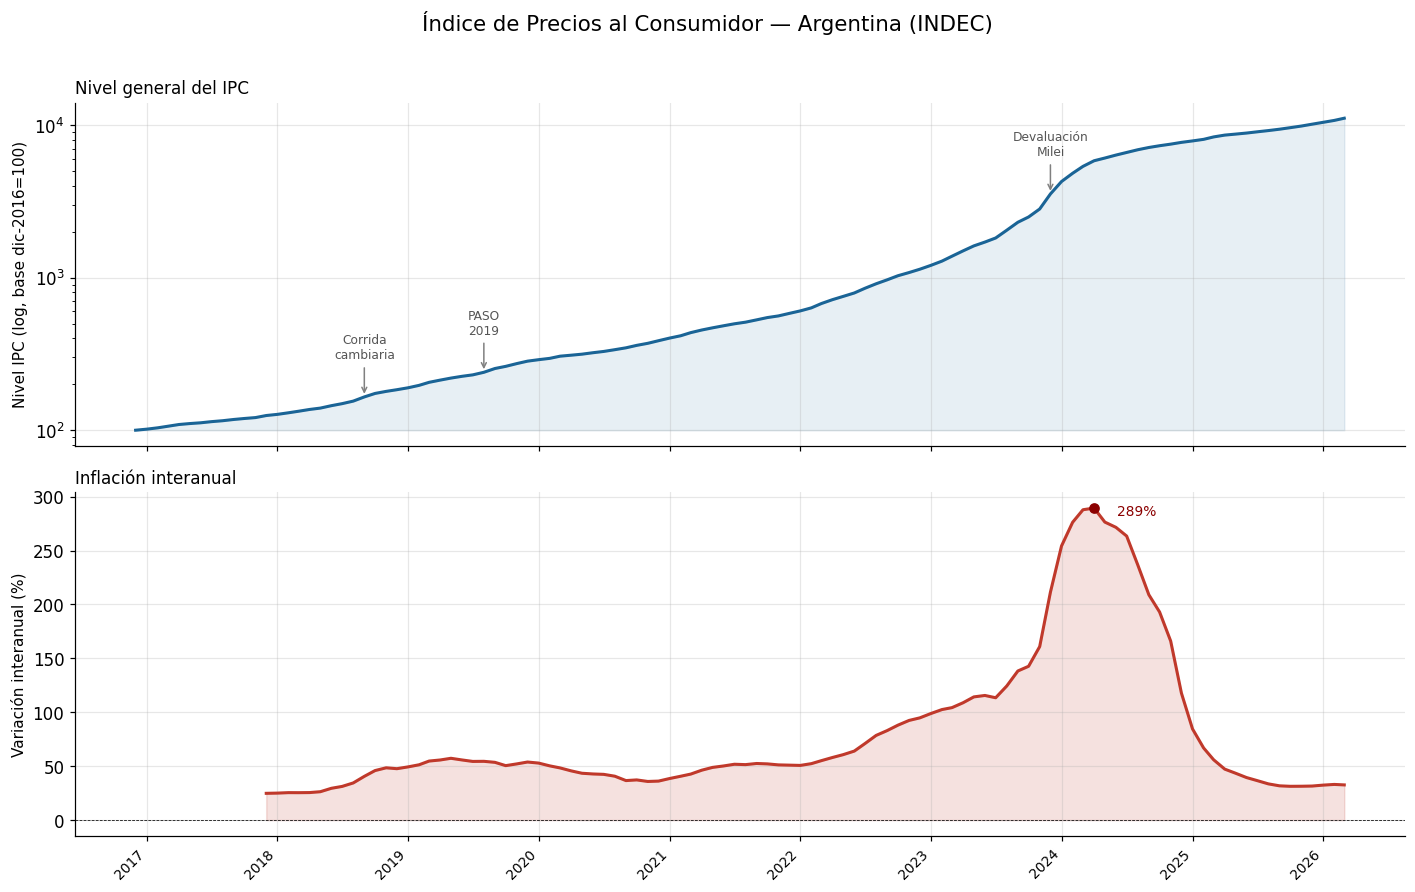


Pico de inflación interanual: 289.4% en April 2024


In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle("Índice de Precios al Consumidor — Argentina (INDEC)",
             fontsize=14, y=1.01)

# Panel 1: Nivel del IPC (escala log)
ax1.plot(df_ipc.index, df_ipc["ipc"], color="#1a6496", linewidth=2)
ax1.fill_between(df_ipc.index, df_ipc["ipc"].min(), df_ipc["ipc"],
                 alpha=0.1, color="#1a6496")
ax1.set_yscale("log")
ax1.set_ylabel("Nivel IPC (log, base dic-2016=100)", fontsize=10)
ax1.set_title("Nivel general del IPC", fontsize=11, loc='left')
# Anotaciones de hitos
hitos = {
    "2018-09-01": ("Corrida\ncambiaria", "top"),
    "2019-08-01": ("PASO\n2019", "top"),
    "2023-12-01": ("Devaluación\nMilei", "top"),
}
for fecha_str, (texto, va) in hitos.items():
    fecha = pd.to_datetime(fecha_str)
    if fecha in df_ipc.index:
        val = df_ipc.loc[fecha, "ipc"]
        ax1.annotate(texto, xy=(fecha, val),
                     xytext=(0, 25), textcoords="offset points",
                     arrowprops=dict(arrowstyle="->", color="gray"),
                     fontsize=8, ha="center", color="#555555")

# Panel 2: Inflación interanual
ax2.plot(df_ipc.index, df_ipc["var_interanual"],
         color="#c0392b", linewidth=2, label="Interanual")
ax2.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax2.fill_between(df_ipc.index, 0, df_ipc["var_interanual"],
                 where=df_ipc["var_interanual"] > 0,
                 alpha=0.15, color="#c0392b")
ax2.set_ylabel("Variación interanual (%)", fontsize=10)
ax2.set_title("Inflación interanual", fontsize=11, loc='left')
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator())

# Marcar máximo
idx_max = df_ipc["var_interanual"].idxmax()
val_max = df_ipc.loc[idx_max, "var_interanual"]
if not pd.isna(val_max):
    ax2.scatter([idx_max], [val_max], color="darkred", zorder=5)
    ax2.annotate(f"{val_max:.0f}%", xy=(idx_max, val_max),
                 xytext=(15, -5), textcoords="offset points",
                 fontsize=9, color="darkred")

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("ipc_nivel_variacion.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"\nPico de inflación interanual: {val_max:.1f}% en {idx_max.strftime('%B %Y')}")


## 4. Media móvil de 6 meses de la variación mensual

La variación mensual es muy volátil: una sola corrección de tarifas o una devaluación abrupta puede generar un pico que distorsiona la lectura de tendencia. La **media móvil de 6 meses** suaviza ese ruido y nos permite ver si la inflación está acelerando o desacelerando estructuralmente.

Esta métrica es la que suelen usar los equipos de política económica para evaluar si los programas de estabilización están funcionando.

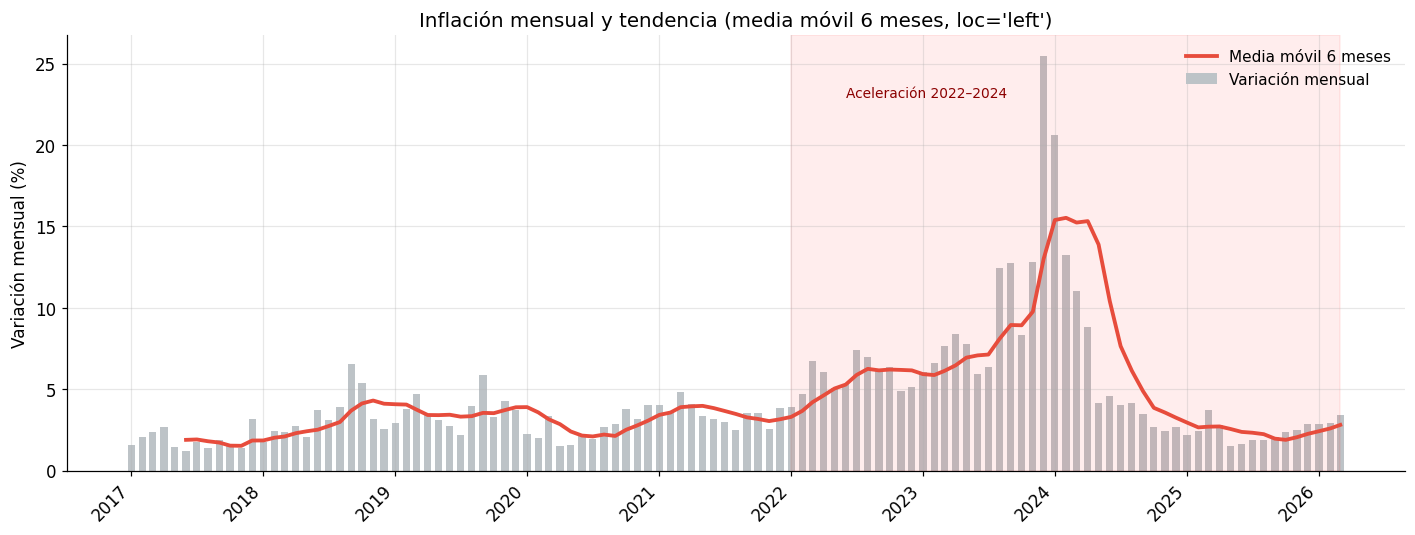

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(df_ipc.index, df_ipc["var_mensual"],
       color="#bdc3c7", width=20, label="Variación mensual")
ax.plot(df_ipc.index, df_ipc["mm6"],
        color="#e74c3c", linewidth=2.5, label="Media móvil 6 meses")

ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Variación mensual (%)", fontsize=11)
ax.set_title("Inflación mensual y tendencia (media móvil 6 meses, loc='left')",
             fontsize=13)
ax.legend(fontsize=10, frameon=False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45, ha="right")

# Sombrear período de alta inflación 2022-2024
ax.axvspan(pd.to_datetime("2022-01-01"), df_ipc.index[-1],
           alpha=0.07, color="red", label="Alta inflación")
ax.text(pd.to_datetime("2022-06-01"), df_ipc["var_mensual"].max() * 0.9,
        "Aceleración 2022–2024", fontsize=9, color="darkred")

plt.tight_layout()
plt.savefig("ipc_mensual_mm6.png", bbox_inches="tight", dpi=150)
plt.show()


## 5. Los 5 meses con mayor inflación mensual

Identificar los picos de inflación mensual es una forma rápida de leer la historia macroeconómica reciente. Cada pico tiene una causa: una devaluación discreta, una liberalización de tarifas, una crisis de confianza en la moneda.

Mes             Inflación  Contexto
Dec 2023           25.5%  Devaluación inicial del gobierno Milei (+118% en 1 día)
Jan 2024           20.6%  Inercia post-devaluación + pass-through
Feb 2024           13.2%  Ver contexto macroeconómico
Nov 2023           12.8%  Ver contexto macroeconómico
Sep 2023           12.8%  Ver contexto macroeconómico


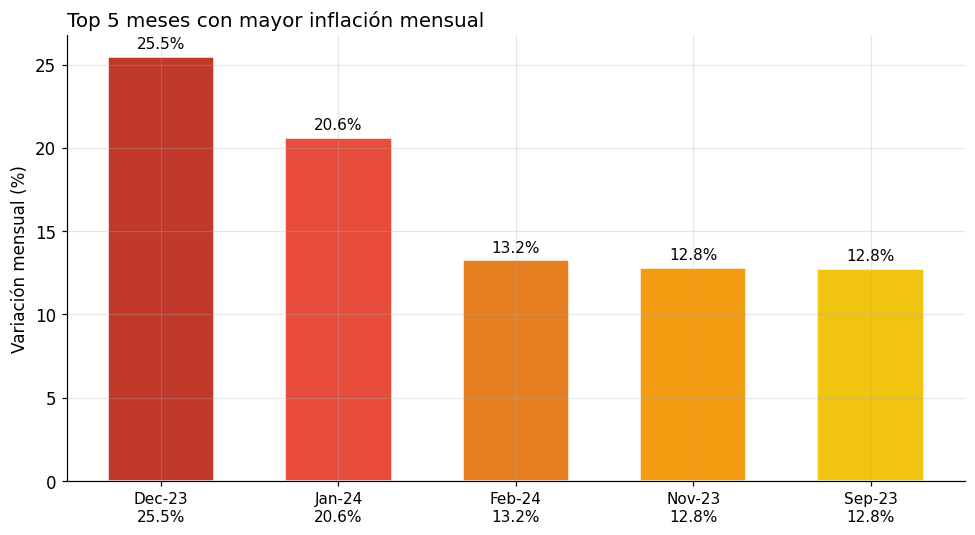

In [7]:
top5 = df_ipc["var_mensual"].nlargest(5).round(2)

# Contexto para cada pico (si la fecha existe en el top5)
contexto = {
    "2023-12": "Devaluación inicial del gobierno Milei (+118% en 1 día)",
    "2024-01": "Inercia post-devaluación + pass-through",
    "2018-09": "Corrida cambiaria, colapso del crawling peg",
    "2019-08": "PASO: depreciación del 30% en un día",
    "2022-07": "Crisis del Palacio de Hacienda, renuncia de Guzmán",
    "2023-08": "Mini-devaluación post-PASO 2023",
}

print("=" * 65)
print(f"{'Mes':<12} {'Inflación':>12}  {'Contexto'}")
print("=" * 65)
for fecha, val in top5.items():
    clave = fecha.strftime("%Y-%m")
    desc = contexto.get(clave, "Ver contexto macroeconómico")
    print(f"{fecha.strftime('%b %Y'):<12} {val:>10.1f}%  {desc}")
print("=" * 65)

# Visualización
fig, ax = plt.subplots(figsize=(9, 5))
colores = ["#c0392b", "#e74c3c", "#e67e22", "#f39c12", "#f1c40f"]
etiquetas = [f"{d.strftime('%b-%y')}\n{v:.1f}%" for d, v in top5.items()]
bars = ax.bar(range(5), top5.values, color=colores, width=0.6, edgecolor="white")
ax.set_xticks(range(5))
ax.set_xticklabels(etiquetas, fontsize=10)
ax.set_ylabel("Variación mensual (%)", fontsize=11)
ax.set_title("Top 5 meses con mayor inflación mensual",
             fontsize=13, loc='left')
for bar, val in zip(bars, top5.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("ipc_top5.png", bbox_inches="tight", dpi=150)
plt.show()


## 6. Análisis político: ciclos macroeconómicos y picos inflacionarios

Los datos de inflación no se entienden sin su contexto institucional. Los tres grandes episodios inflacionarios que registra esta serie (2018, 2019 y 2023-2024) tienen causas distintas pero comparten un mecanismo: **un shock cambiario que se propaga a precios a través del pass-through**.

El **pass-through** (o traspaso cambiario a precios) describe cuánto de una depreciación del peso termina traduciéndose en aumento de precios internos. En Argentina, estimaciones recientes sugieren un pass-through de corto plazo de entre 0.3 y 0.7 (por cada 10% de depreciación, los precios suben entre 3% y 7%).

La siguiente tabla sintetiza los grandes ciclos de la serie:

In [8]:
ciclos = [
    ("2017", "2017-12", "Gradualismo Cambiemos",
     "Corrección gradual de precios relativos. Inflación ~25% anual."),
    ("2018", "2018-12", "Crisis de balanza de pagos",
     "Corrida cambiaria. El peso se deprecia un 50%. Pass-through al IPC."),
    ("2019", "2019-12", "Año electoral y PASO",
     "Las PASO del 11-ago-2019 generan un salto cambiario del 30% en un día."),
    ("2020", "2021-12", "Pandemia y cepo cambiario",
     "Inflación cedular pero brecha cambiaria creciente. Nominalismo reprimido."),
    ("2022", "2022-12", "Inestabilidad ministerial",
     "Tres ministros de economía en un año. Inflación escala al 94%."),
    ("2023", "2023-12", "Hiperinflación cambiaria",
     "Devaluación del 118% en diciembre. Inflación mensual histórica."),
    ("2024", "2024-12", "Programa de estabilización",
     "Crawling peg al 2% mensual. Inflación desciende pero permanece alta."),
]

print(f"{'Período':<8} {'Régimen':<35} {'Nota'}")
print("-" * 85)
for inicio, fin, regimen, nota in ciclos:
    print(f"{inicio:<8} {regimen:<35} {nota}")

Período  Régimen                             Nota
-------------------------------------------------------------------------------------
2017     Gradualismo Cambiemos               Corrección gradual de precios relativos. Inflación ~25% anual.
2018     Crisis de balanza de pagos          Corrida cambiaria. El peso se deprecia un 50%. Pass-through al IPC.
2019     Año electoral y PASO                Las PASO del 11-ago-2019 generan un salto cambiario del 30% en un día.
2020     Pandemia y cepo cambiario           Inflación cedular pero brecha cambiaria creciente. Nominalismo reprimido.
2022     Inestabilidad ministerial           Tres ministros de economía en un año. Inflación escala al 94%.
2023     Hiperinflación cambiaria            Devaluación del 118% en diciembre. Inflación mensual histórica.
2024     Programa de estabilización          Crawling peg al 2% mensual. Inflación desciende pero permanece alta.


## 7. Tipo de cambio: comparación entre devaluación e inflación

Una de las preguntas más importantes en macroeconomía argentina es: ¿el tipo de cambio oficial va adelante o atrás de la inflación? Cuando el tipo de cambio sube más lento que los precios, el **tipo de cambio real se aprecia**, lo que erosiona la competitividad exportadora. Cuando sube más rápido, genera un shock inflacionario.

Vamos a descargar la serie del tipo de cambio oficial (BCRA), remuestrearla a frecuencia mensual y compararla con la inflación.

In [9]:
FALLBACK_TC = [
    ["2017-01-01", 15.9], ["2017-06-01", 16.7], ["2017-12-01", 18.8],
    ["2018-01-01", 19.0], ["2018-06-01", 27.5], ["2018-09-01", 40.5],
    ["2018-12-01", 37.7], ["2019-01-01", 38.6], ["2019-08-01", 55.9],
    ["2019-09-01", 56.5], ["2019-12-01", 63.0], ["2020-01-01", 63.1],
    ["2020-06-01", 70.4], ["2020-12-01", 84.2], ["2021-06-01", 95.3],
    ["2021-12-01", 102.7], ["2022-06-01", 125.5], ["2022-07-01", 136.0],
    ["2022-12-01", 177.2], ["2023-06-01", 258.0], ["2023-08-01", 350.0],
    ["2023-12-01", 808.5], ["2024-01-01", 832.0], ["2024-06-01", 920.0],
    ["2024-12-01", 1025.0],
]

URL_TC = "https://apis.datos.gob.ar/series/api/series/?ids=92.2_TIPO_CAMBIION_0_0_21_24&last=1500&format=json"
raw_tc = fetch_series(URL_TC, FALLBACK_TC)

df_tc = pd.DataFrame(raw_tc, columns=["fecha", "tc"])
df_tc["fecha"] = pd.to_datetime(df_tc["fecha"])
df_tc = df_tc.set_index("fecha").sort_index()

# Remuestreo mensual (promedio del mes)
df_tc_m = df_tc["tc"].resample("MS").mean().to_frame()
df_tc_m["var_mensual_tc"] = df_tc_m["tc"].pct_change(1) * 100
df_tc_m["var_interanual_tc"] = df_tc_m["tc"].pct_change(12) * 100

print(f"Tipo de cambio: {df_tc_m.index[0].strftime('%Y-%m')} → {df_tc_m.index[-1].strftime('%Y-%m')}")
print(f"Frecuencia original: {'diaria' if len(df_tc) > len(df_tc_m) * 2 else 'mensual o menor'}")
df_tc_m.tail(4)

API OK — 1500 observaciones descargadas.
Tipo de cambio: 2022-01 → 2026-03
Frecuencia original: diaria


,tc,var_mensual_tc,var_interanual_tc
fecha,,,
2025-12-01,1447.362906,1.298801,41.638519
2026-01-01,1449.799481,0.168346,39.023967
2026-02-01,1408.633204,-2.839446,33.128401
2026-03-01,1408.980863,0.024681,31.839275


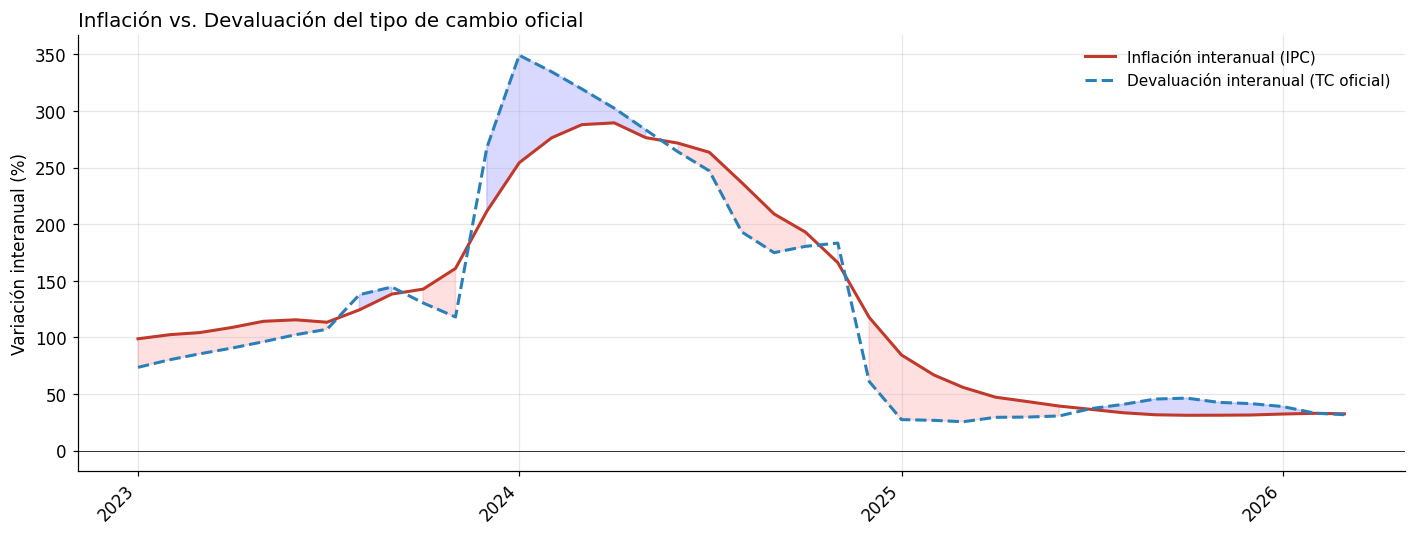


Correlación entre inflación interanual y devaluación interanual: 0.958


In [10]:
# Alinear ambas series al período en común
df_comp = pd.DataFrame({
    "ipc_ia": df_ipc["var_interanual"],
    "tc_ia": df_tc_m["var_interanual_tc"]
}).dropna()

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df_comp.index, df_comp["ipc_ia"],
        color="#c0392b", linewidth=2, label="Inflación interanual (IPC)")
ax.plot(df_comp.index, df_comp["tc_ia"],
        color="#2980b9", linewidth=2, linestyle="--",
        label="Devaluación interanual (TC oficial)")

ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Variación interanual (%)", fontsize=11)
ax.set_title("Inflación vs. Devaluación del tipo de cambio oficial",
             fontsize=13, loc='left')
ax.legend(fontsize=10, frameon=False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45, ha="right")

# Sombrear períodos donde TC > IPC (devaluación > inflación)
ax.fill_between(df_comp.index,
                df_comp["tc_ia"], df_comp["ipc_ia"],
                where=df_comp["tc_ia"] > df_comp["ipc_ia"],
                alpha=0.15, color="blue",
                label="TC sube más que inflación")
ax.fill_between(df_comp.index,
                df_comp["tc_ia"], df_comp["ipc_ia"],
                where=df_comp["tc_ia"] < df_comp["ipc_ia"],
                alpha=0.12, color="red",
                label="Atraso cambiario")

plt.tight_layout()
plt.savefig("tc_vs_ipc.png", bbox_inches="tight", dpi=150)
plt.show()

# Correlación
corr = df_comp.corr().loc["ipc_ia", "tc_ia"]
print(f"\nCorrelación entre inflación interanual y devaluación interanual: {corr:.3f}")


### Interpretación del gráfico

Las zonas azules indican períodos donde el tipo de cambio se depreció más rápido que la inflación — típicamente en los momentos de shock cambiario agudo (2018, 2019, diciembre 2023). Las zonas rojas indican **atraso cambiario**: la inflación supera a la devaluación, lo que erosiona la competitividad exportadora y suele preceder una corrección cambiaria.

La alta correlación entre ambas series confirma el mecanismo de pass-through: en Argentina, los movimientos del tipo de cambio son uno de los principales determinantes de la inflación en el corto plazo.

---

> **Para pensar**: ¿Por qué un gobierno podría preferir un esquema de "crawling peg" (depreciación programada a tasa fija) en lugar de un tipo de cambio libre? ¿Qué trade-offs implica para la inflación, la competitividad y las reservas?

---

## Ejercicios

### Ejercicio 1 — Inflación acumulada por año

Calculá la inflación acumulada para cada año calendario completo en la serie. La inflación anual acumulada **no** es la suma de las variaciones mensuales sino el producto:

$$\pi_{\text{anual}} = \prod_{i=1}^{12} (1 + \pi_i^{\text{mensual}}/100) - 1$$

Presentá los resultados en una tabla ordenada de menor a mayor inflación. ¿En qué año fue mayor? ¿Coincide con el pico de inflación interanual que viste en los gráficos?

```python
# Tu código aquí
```

---

### Ejercicio 2 — Estacionalidad de la inflación

Calculá la inflación promedio para cada mes del año (enero promedio, febrero promedio, etc.) usando `groupby`. ¿Existe algún patrón estacional? ¿Qué meses tienden a tener inflación más alta o más baja? Relacioná tu respuesta con los calendarios de ajuste de tarifas y paritarias en Argentina.

Graficá el resultado como un gráfico de barras horizontal.

```python
# Tu código aquí
```

---

### Ejercicio 3 — Correlación rezagada entre tipo de cambio e inflación

El pass-through cambiario no es instantáneo: una devaluación tarda varios meses en transmitirse plenamente a los precios. Calculá la correlación entre la **variación mensual del tipo de cambio** y la **variación mensual del IPC** para los rezagos 0, 1, 2, 3, 4 y 5 meses (es decir, ¿cuánto predice el TC de este mes la inflación de los próximos meses?).

Graficá las correlaciones en función del rezago. ¿En qué rezago es máxima? ¿Qué implicancias tiene esto para el diseño de política monetaria?

```python
# Tu código aquí
```